# Hackathon 6 — Bank Marketing (UCI)
## Parte 1: Análisis y modelado · Parte 2: Entrenamiento final

**Problema.** Predecir si un cliente contratará un depósito a plazo (`y ∈ {yes, no}`) a partir de los datos
disponibles **antes** de llamarlo.

**Restricción crítica.** La variable `duration` no puede usarse: solo se conoce cuando la llamada ya terminó.
Usarla sería *data leakage* y produciría un modelo inservible en producción.

**Índice**
1. Carga y exploración del dataset
2. Análisis de fuentes de leakage
3. Selección de variables y feature engineering
4. Entrenamiento y comparación de 3 modelos
5. Calibración del umbral de decisión
6. Evaluación en test
7. Entrenamiento final con todos los datos y serialización
8. Prueba de la función `predict(input_dict)`

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Permite importar el paquete `app` (mismo contrato de features que usa la API)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from app.features import (
    RAW_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES, MODEL_FEATURES,
    TARGET, TARGET_MAP, FORBIDDEN_FEATURES, build_features,
)

SEED = 42
print("Features que recibe la API:", len(RAW_FEATURES))
print("Variables prohibidas:", FORBIDDEN_FEATURES)

Features que recibe la API: 19
Variables prohibidas: ['duration']


## 1. Carga y exploración del dataset

Usamos `bank-additional-full.csv` (41.188 filas, 20 features + target), la versión recomendada por los
autores porque incluye los indicadores macroeconómicos. Si no lo tienes, ejecuta `python src/download_data.py`.

In [2]:
df = pd.read_csv(ROOT / "data" / "bank-additional-full.csv", sep=";")
print("Dimensiones:", df.shape)
print("Duplicados exactos:", df.duplicated().sum())
print("Nulos:", df.isna().sum().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.head()

Dimensiones: (41188, 21)
Duplicados exactos: 12
Nulos: 0


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


y
no     88.73
yes    11.27


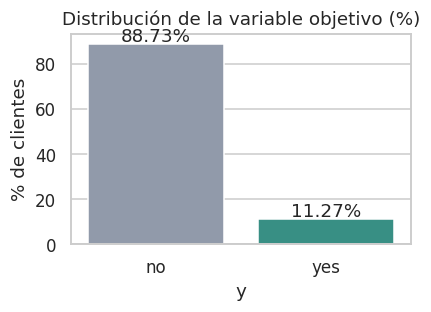

In [3]:
# Distribución del target: el dataset está fuertemente desbalanceado
dist = df[TARGET].value_counts(normalize=True).mul(100).round(2)
print(dist.to_string())

fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(x=dist.index, y=dist.values, ax=ax, palette=["#8d99ae", "#2a9d8f"])
ax.set_title("Distribución de la variable objetivo (%)")
ax.set_ylabel("% de clientes")
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.tight_layout(); plt.show()

Solo **11.3%** de los clientes acepta. Consecuencias directas sobre la evaluación:

- La *accuracy* es inútil: un modelo que siempre diga `no` acierta el 88.7%.
- Usaremos **F1 (clase yes)**, **balanced accuracy**, **ROC-AUC** y **PR-AUC**.
- Para seleccionar modelo usamos **PR-AUC** (independiente del umbral y sensible a la clase minoritaria).

In [4]:
# Valores 'unknown': funcionan como nulos enmascarados
unknowns = {c: (df[c] == "unknown").mean() * 100 for c in CATEGORICAL_FEATURES}
unknowns = pd.Series(unknowns).sort_values(ascending=False)
print(unknowns[unknowns > 0].round(2).to_string())

default      20.88
education     4.20
housing       2.40
loan          2.40
job           0.80
marital       0.19


Decisión: **no imputamos** `unknown`; lo tratamos como una categoría más. En campañas telefónicas,
que un dato falte suele ser informativo por sí mismo (y el one-hot lo captura sin esfuerzo).

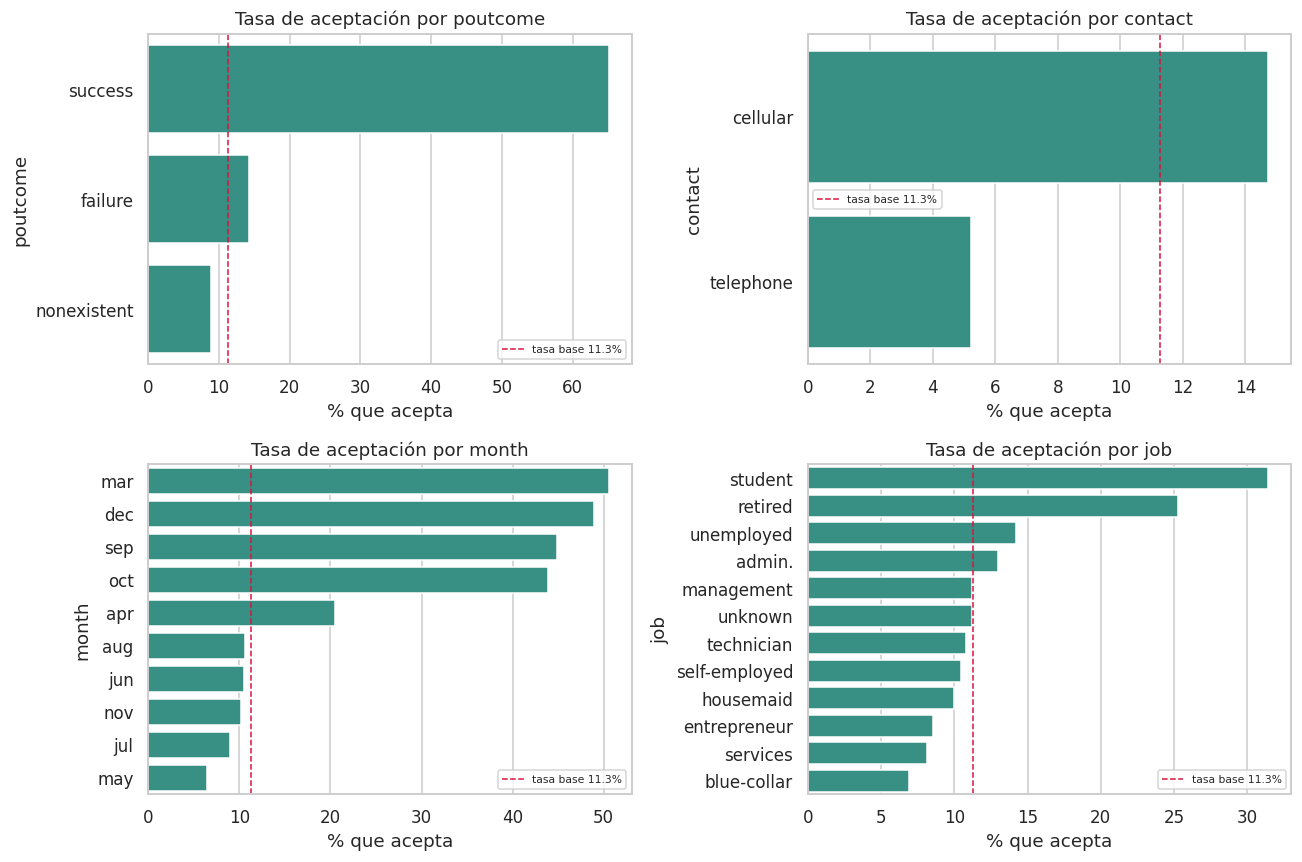

In [5]:
# Tasa de aceptación por variable categórica: dónde está la señal
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["poutcome", "contact", "month", "job"]):
    tasa = (df.groupby(col)[TARGET].apply(lambda s: (s == "yes").mean() * 100)
              .sort_values(ascending=False))
    sns.barplot(x=tasa.values, y=tasa.index, ax=ax, color="#2a9d8f")
    ax.axvline(11.27, color="crimson", ls="--", lw=1, label="tasa base 11.3%")
    ax.set_title(f"Tasa de aceptación por {col}")
    ax.set_xlabel("% que acepta"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Lecturas clave:

- `poutcome = success` dispara la aceptación por encima del 60%: quien ya contrató antes, vuelve a contratar.
- El contacto por **celular** funciona mucho mejor que el teléfono fijo.
- Meses con poco volumen (mar, dec, sep, oct) tienen tasas altísimas; mayo, el mes con más llamadas, tiene
  de las tasas más bajas. Hay un efecto de campaña masiva mal segmentada.
- `student` y `retired` son los perfiles más receptivos.

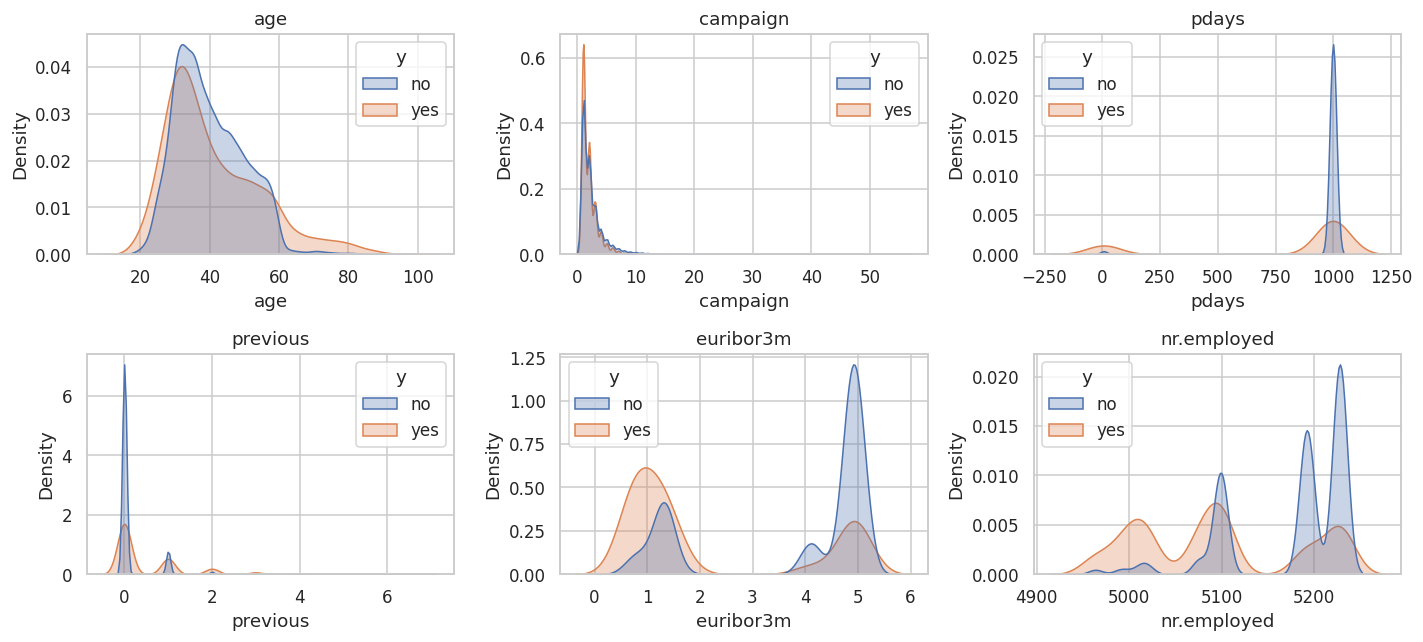

In [6]:
# Variables numéricas frente al target
num_cols = ["age", "campaign", "pdays", "previous", "euribor3m", "nr.employed"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, col in zip(axes.ravel(), num_cols):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, alpha=.3, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 2. Análisis de fuentes de leakage

Este es el punto que decide si el modelo sirve o no en producción.

Correlación de `duration` con el target: 0.405
      mean    50%     max
y                        
no   220.9  164.0  4918.0
yes  553.3  449.0  4199.0


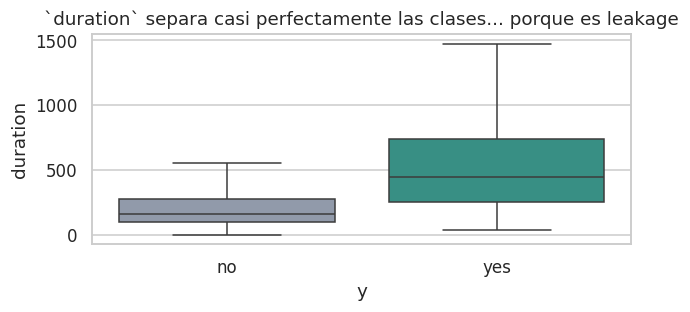

In [7]:
y_bin = (df[TARGET] == "yes").astype(int)
corr_duration = df["duration"].corr(y_bin)
print(f"Correlación de `duration` con el target: {corr_duration:.3f}")
print(df.groupby(TARGET)["duration"].describe()[["mean", "50%", "max"]].round(1).to_string())

fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(data=df, x=TARGET, y="duration", ax=ax, showfliers=False, palette=["#8d99ae", "#2a9d8f"])
ax.set_title("`duration` separa casi perfectamente las clases... porque es leakage")
plt.tight_layout(); plt.show()

**(a) `duration` — leakage claro.** La duración de la llamada solo existe *después* de la llamada:
si dura 0 segundos, el resultado es siempre `no`. En el momento de decidir a quién llamar ese dato no
existe. **Acción: se elimina antes de cualquier split.**

**(b) Variables macroeconómicas** (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`,
`nr.employed`) — **no son leakage**: se publican antes de la llamada. Sí introducen dependencia temporal:
el modelo aprende la coyuntura 2008-2010, así que hay que vigilar el *drift* y reentrenar.
**Acción: se conservan y se documenta el riesgo.**

**(c) `pdays`, `previous`, `poutcome`** — describen campañas *anteriores*, conocidas antes de llamar. No es leakage.

**(d) Leakage metodológico.** Escalar o codificar usando estadísticas del conjunto completo también es
leakage. Por eso todo el preprocesamiento vive dentro de un `Pipeline` de scikit-learn, que se ajusta
solo con los datos de entrenamiento de cada fold.

In [8]:
# Restricción crítica aplicada
df = df.drop(columns=FORBIDDEN_FEATURES)
assert "duration" not in df.columns
print("Columnas restantes:", df.shape[1])

Columnas restantes: 20


## 3. Selección de variables y feature engineering

Mantenemos las 19 features restantes (ninguna es redundante ni constante) y añadimos dos transformaciones
deterministas sobre `pdays`:

| Nueva variable | Definición | Por qué |
|---|---|---|
| `was_contacted_before` | `1` si `pdays != 999` | Extrae la señal binaria escondida en el centinela |
| `pdays_clean` | `pdays`, con `999 → -1` | Dejar el 999 mezcla una categoría con una escala de días y distorsiona los modelos lineales |

Esta lógica vive en `app/features.py` y la usan **tanto el entrenamiento como la API**, para que sea
imposible que ambos preprocesen distinto (*training/serving skew*).

In [9]:
X = build_features(df[RAW_FEATURES])
y = df[TARGET].map(TARGET_MAP).astype(int)

print(f"X: {X.shape}  |  features: {len(MODEL_FEATURES)}")
print("Numéricas  :", NUMERIC_FEATURES)
print("Categóricas:", CATEGORICAL_FEATURES)
X.head(3)

X: (41176, 20)  |  features: 20
Numéricas  : ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_clean', 'was_contacted_before']
Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_clean,was_contacted_before,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,-1,0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,-1,0,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,-1,0,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print("Proporción de 'yes' -> train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))

Train: 32,940  |  Test: 8,236
Proporción de 'yes' -> train: 0.1127 | test: 0.1127


## 4. Entrenamiento y comparación de modelos

Tres familias distintas, cada una con búsqueda de hiperparámetros por validación cruzada estratificada:

| Modelo | Por qué lo incluimos |
|---|---|
| Regresión logística | Baseline lineal, interpretable, rápido |
| Random Forest | No lineal, robusto a outliers y escalas |
| HistGradientBoosting | Boosting moderno, suele ganar en datos tabulares |

Los dos primeros usan `class_weight` balanceado para compensar el desbalance.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict

def construir_preprocesador():
    return ColumnTransformer([
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ])

modelos = {
    "logistic_regression": (
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    "random_forest": (
        RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample",
                               n_jobs=-1, random_state=SEED),
        {"clf__max_depth": [10, 20], "clf__min_samples_leaf": [5, 20]},
    ),
    "hist_gradient_boosting": (
        HistGradientBoostingClassifier(max_iter=400, early_stopping=True,
                                       validation_fraction=0.1, random_state=SEED),
        {"clf__learning_rate": [0.05, 0.1], "clf__max_leaf_nodes": [31, 63]},
    ),
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [12]:
import time
busquedas, filas = {}, []

for nombre, (estimador, grid) in modelos.items():
    pipe = Pipeline([("prep", construir_preprocesador()), ("clf", estimador)])
    gs = GridSearchCV(pipe, grid, scoring="average_precision", cv=cv, n_jobs=-1)
    t = time.time(); gs.fit(X_train, y_train); seg = time.time() - t
    busquedas[nombre] = gs
    filas.append({"modelo": nombre, "pr_auc_cv": round(gs.best_score_, 4),
                  "mejores_params": gs.best_params_, "segundos": round(seg, 1)})
    print(f"{nombre:<24} PR-AUC={gs.best_score_:.4f}  {gs.best_params_}  [{seg:.1f}s]")

tabla = pd.DataFrame(filas).sort_values("pr_auc_cv", ascending=False).reset_index(drop=True)
tabla

logistic_regression      PR-AUC=0.4439  {'clf__C': 1.0}  [2.6s]


random_forest            PR-AUC=0.4645  {'clf__max_depth': 10, 'clf__min_samples_leaf': 5}  [58.5s]


hist_gradient_boosting   PR-AUC=0.4598  {'clf__learning_rate': 0.05, 'clf__max_leaf_nodes': 31}  [10.5s]


,modelo,pr_auc_cv,mejores_params,segundos
0,random_forest,0.4645,"{'clf__max_depth': 10, 'clf__min_samples_leaf'...",58.5
1,hist_gradient_boosting,0.4598,"{'clf__learning_rate': 0.05, 'clf__max_leaf_no...",10.5
2,logistic_regression,0.4439,{'clf__C': 1.0},2.6


In [13]:
mejor_nombre = tabla.loc[0, "modelo"]
mejor = busquedas[mejor_nombre].best_estimator_
print("Modelo seleccionado:", mejor_nombre)
print("Hiperparámetros   :", busquedas[mejor_nombre].best_params_)

Modelo seleccionado: random_forest
Hiperparámetros   : {'clf__max_depth': 10, 'clf__min_samples_leaf': 5}


**Decisión.** Los tres modelos quedan muy cerca (PR-AUC entre 0.44 y 0.47), lo que indica que sin
`duration` la señal disponible es limitada y que el problema es intrínsecamente difícil. Elegimos el de
mayor PR-AUC en validación cruzada.

## 5. Calibración del umbral de decisión

El umbral por defecto (0.5) no es el óptimo cuando las clases están desbalanceadas. Buscamos el umbral que
maximiza F1 usando predicciones **out-of-fold** del conjunto de entrenamiento — nunca el test, porque eso
sería otra forma de leakage.

Umbral óptimo: 0.63  ->  F1 out-of-fold = 0.5008
Con el umbral 0.50        F1 out-of-fold = 0.4796


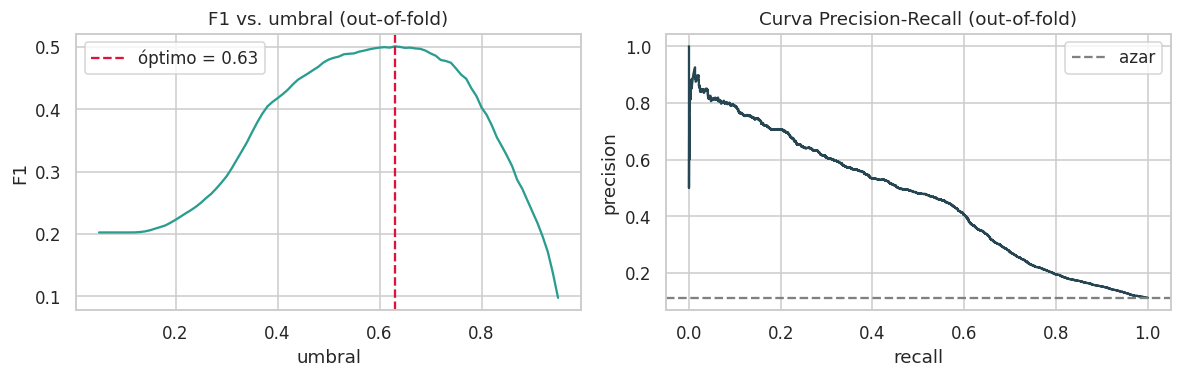

In [14]:
from sklearn.metrics import f1_score, precision_recall_curve

p_oof = cross_val_predict(mejor, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

umbrales = np.arange(0.05, 0.96, 0.01)
f1s = [f1_score(y_train, (p_oof >= t).astype(int)) for t in umbrales]
thr = float(umbrales[int(np.argmax(f1s))]); f1_oof = max(f1s)

print(f"Umbral óptimo: {thr:.2f}  ->  F1 out-of-fold = {f1_oof:.4f}")
print(f"Con el umbral 0.50        F1 out-of-fold = {f1_score(y_train, (p_oof >= .5).astype(int)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(umbrales, f1s, color="#2a9d8f")
axes[0].axvline(thr, ls="--", color="crimson", label=f"óptimo = {thr:.2f}")
axes[0].set_xlabel("umbral"); axes[0].set_ylabel("F1"); axes[0].set_title("F1 vs. umbral (out-of-fold)")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_train, p_oof)
axes[1].plot(rec, prec, color="#264653")
axes[1].axhline(y_train.mean(), ls="--", color="grey", label="azar")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Curva Precision-Recall (out-of-fold)"); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluación en el conjunto de test

Datos nunca vistos, con el umbral calibrado en el paso anterior.

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, balanced_accuracy_score,
                             precision_score, recall_score, RocCurveDisplay)

p_test = mejor.predict_proba(X_test)[:, 1]
y_pred = (p_test >= thr).astype(int)

metricas = {
    "f1": f1_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, p_test),
    "pr_auc": average_precision_score(y_test, p_test),
}
print(pd.Series(metricas).round(4).to_string())
print()
print(classification_report(y_test, y_pred, target_names=["no", "yes"], digits=3))

f1                   0.5240
balanced_accuracy    0.7524
precision            0.4723
recall               0.5884
roc_auc              0.8130
pr_auc               0.4828

              precision    recall  f1-score   support

          no      0.946     0.917     0.931      7308
         yes      0.472     0.588     0.524       928

    accuracy                          0.880      8236
   macro avg      0.709     0.752     0.728      8236
weighted avg      0.893     0.880     0.885      8236



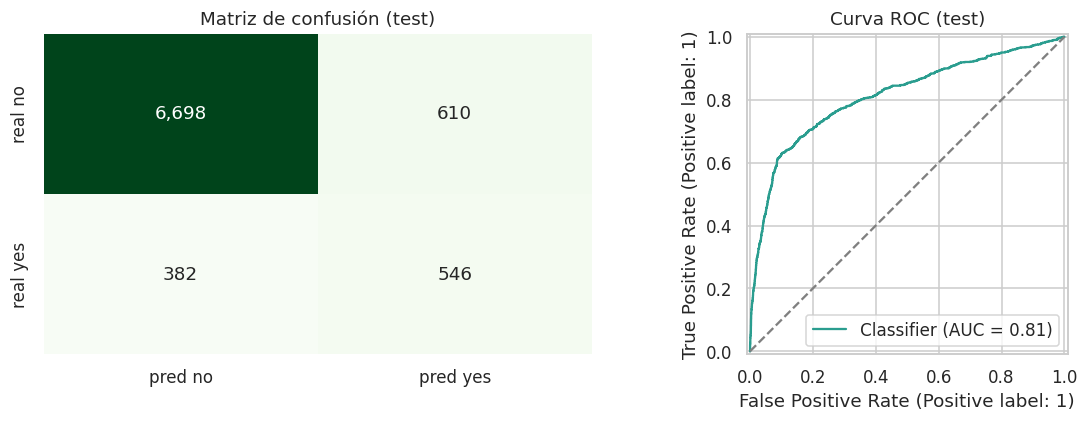

De cada 100 clientes que el modelo recomienda llamar, ~47 contratan.
Sin modelo, llamando al azar, contratarían ~11 de cada 100.
Mejora de eficiencia del contacto: x4.2


In [16]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, ax=axes[0],
            xticklabels=["pred no", "pred yes"], yticklabels=["real no", "real yes"])
axes[0].set_title("Matriz de confusión (test)")
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[1], color="#2a9d8f")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_title("Curva ROC (test)")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"De cada 100 clientes que el modelo recomienda llamar, ~{100*tp/(tp+fp):.0f} contratan.")
print(f"Sin modelo, llamando al azar, contratarían ~{100*y_test.mean():.0f} de cada 100.")
print(f"Mejora de eficiencia del contacto: x{(tp/(tp+fp))/y_test.mean():.1f}")

**Interpretación de negocio.** El valor del modelo no está en la exactitud sino en la **priorización**:
multiplica por ~4 la tasa de éxito por llamada frente a llamar al azar. Con `recall ≈ 0.59` capturamos algo
más de la mitad de los clientes interesados; subir el recall exigiría bajar el umbral y llamar a mucha más
gente. El umbral es, en la práctica, la perilla de negocio: presupuesto de llamadas vs. cobertura.

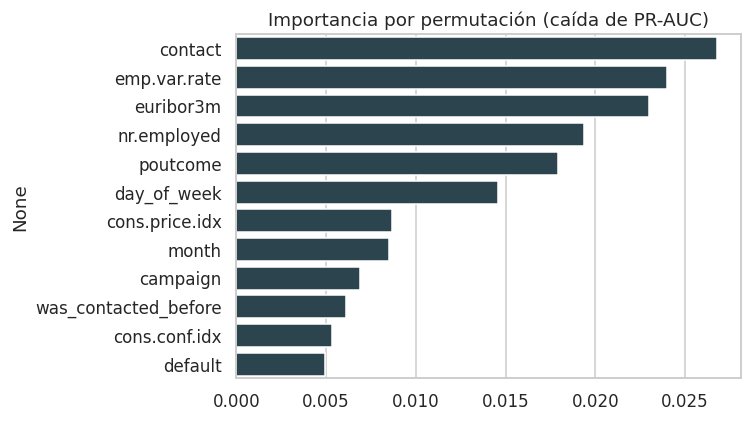

In [17]:
# ¿Qué variables pesan más? (importancia por permutación, sobre una muestra por velocidad)
from sklearn.inspection import permutation_importance

idx = np.random.RandomState(SEED).choice(len(X_test), 3000, replace=False)
imp = permutation_importance(mejor, X_test.iloc[idx], y_test.iloc[idx],
                             n_repeats=5, random_state=SEED, scoring="average_precision", n_jobs=-1)
serie = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=serie.values, y=serie.index, color="#264653", ax=ax)
ax.set_title("Importancia por permutación (caída de PR-AUC)")
plt.tight_layout(); plt.show()

## 7. Parte 2 — Entrenamiento final y serialización

Reentrenamos el modelo ganador con **todos** los datos (train + test) y los mejores hiperparámetros, y
guardamos un único artefacto que contiene el pipeline completo, el umbral calibrado, los metadatos y las
métricas de referencia.

> Nota: reentrenar con el 100% es lo que pide la actividad y es lo correcto para producción (más datos =
> mejor modelo), pero implica que a partir de ese momento ya no tenemos un conjunto limpio para evaluar.
> Por eso las métricas que se reportan y se guardan son las del *holdout* del paso 6.

In [18]:
import joblib, sklearn, platform
from datetime import datetime, timezone

mejores_params = {k.replace("clf__", ""): v for k, v in busquedas[mejor_nombre].best_params_.items()}
estimador_final = modelos[mejor_nombre][0].set_params(**mejores_params)
pipeline_final = Pipeline([("prep", construir_preprocesador()), ("clf", estimador_final)])
pipeline_final.fit(X, y)

artefacto = {
    "pipeline": pipeline_final,
    "threshold": thr,
    "metadata": {
        "model_version": "1.0.0",
        "model_name": mejor_nombre,
        "best_params": mejores_params,
        "raw_features": RAW_FEATURES,
        "model_features": MODEL_FEATURES,
        "excluded_features": FORBIDDEN_FEATURES,
        "target_map": TARGET_MAP,
        "n_rows_final_fit": int(X.shape[0]),
        "decision_threshold": round(thr, 4),
        "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "sklearn_version": sklearn.__version__,
        "python_version": platform.python_version(),
        "dataset": "Bank Marketing (UCI) - bank-additional-full.csv",
    },
    "metrics": {"test_holdout": {k: round(v, 4) for k, v in metricas.items()},
                "umbral": {"valor": round(thr, 4), "f1_out_of_fold": round(f1_oof, 4)}},
}

(ROOT / "models").mkdir(exist_ok=True)
joblib.dump(artefacto, ROOT / "models" / "model.joblib", compress=3)
print("Guardado:", (ROOT / "models" / "model.joblib").stat().st_size / 1e6, "MB")

Guardado: 5.959103 MB


## 8. Parte 3 — Prueba de la función `predict(input_dict)`

La función vive en `app/predict.py` y es la que usa la API. Aquí comprobamos los tres comportamientos que
pide el enunciado: recibe un diccionario, valida la entrada y devuelve predicción + probabilidades.

In [19]:
import importlib
import app.predict as P
importlib.reload(P)
P.load_model.cache_clear()

cliente = {
    "age": 24, "job": "student", "marital": "single", "education": "high.school",
    "default": "no", "housing": "no", "loan": "no", "contact": "cellular",
    "month": "mar", "day_of_week": "tue", "campaign": 1, "pdays": 6, "previous": 2,
    "poutcome": "success", "emp.var.rate": -1.8, "cons.price.idx": 92.843,
    "cons.conf.idx": -50.0, "euribor3m": 1.266, "nr.employed": 5099.1,
}
print(json.dumps(P.predict(cliente), indent=2, ensure_ascii=False))

{
  "prediction": "yes",
  "prediction_label": "Contratará el depósito a plazo",
  "probabilities": {
    "no": 0.2088,
    "yes": 0.7912
  },
  "confidence": 0.7912,
  "confidence_level": "media",
  "threshold": 0.63,
  "model_version": "1.0.0",
  "warnings": []
}


In [20]:
# Validación: categoría inexistente
try:
    P.predict({**cliente, "job": "astronauta"})
except P.InputValidationError as e:
    print("Rechazado:", e.errors[0][:120], "...")

# Validación: campo faltante
try:
    P.predict({k: v for k, v in cliente.items() if k != "age"})
except P.InputValidationError as e:
    print("Rechazado:", e.errors[0])

# `duration` se ignora explícitamente
r = P.predict({**cliente, "duration": 600})
print("Con duration ->", r["prediction"], "| avisos:", len(r["warnings"]))

Rechazado: 'job': valor 'astronauta' no válido. Admitidos: ['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 're ...
Rechazado: Faltan campos obligatorios: ['age']
Con duration -> yes | avisos: 2


## Conclusiones

1. **Sin `duration`, el problema es mucho más difícil** — y mucho más honesto. Las métricas publicadas en
   internet con `duration` incluida (AUC > 0.93) no son replicables en producción.
2. El mejor modelo alcanza **ROC-AUC ≈ 0.81** y **F1 ≈ 0.52** con el umbral calibrado, frente a una tasa
   base del 11%. Como herramienta de priorización de llamadas, multiplica por ~4 la eficiencia del contacto.
3. La señal más fuerte está en el **historial** (`poutcome`, `pdays`) y en el **contexto macroeconómico**
   (`euribor3m`, `nr.employed`), no en el perfil demográfico.
4. El sistema se clasifica como **nivel 2 (Recomendación)**; el análisis de riesgos está en
   `docs/parte6_nivel_sistema.md`.

Siguientes pasos: la API (`app/main.py`), el contenedor (`Dockerfile`) y el despliegue en Cloud Run
(`docs/despliegue_gcp.md`).